# T-DEV-810 - Analyse X-ray - K-Nearest Neighbors

In [46]:
import os
from import_ipynb import NotebookFinder
import importlib
from imblearn.under_sampling import RandomUnderSampler
import numpy as np
import shutil
from huggingface_hub import hf_hub_download
import joblib

## Chargement des fichiers + Lancer de preprocessing du dataset
Charger les fichiers permet de récupérer leurs methods.
    - [on_the_fly_augmentation.ipynb](../../on_the_fly_augmentation.ipynb)
    - [dataset.ipynb](../notebooks/utility/dataset.ipynb)
    - [knn_pca.ipynb](../notebooks/process/knn_pca.ipynb)
    - [knn_lda.ipynb](../notebooks/process/knn_lda.ipynb)

Libraries imported successfully!

Augmentation pipelines created!

Loading dataset...


c:\Tools\python\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
Using the latest cached version of the dataset since PAR8/chest-xray-pneumonia couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\Aïda\.cache\huggingface\datasets\PAR8___chest-xray-pneumonia\default\0.0.0\42d3b32e6fc8f1c1974fd14f23bb49e7a130b801 (last modified on Mon Mar  9 21:58:36 2026).



  Dataset loaded!
  Train: 4705 images
  Validation: 522 images
  Test: 624 images

 Transforms applied!
 Images will be augmented on-the-fly when you load them


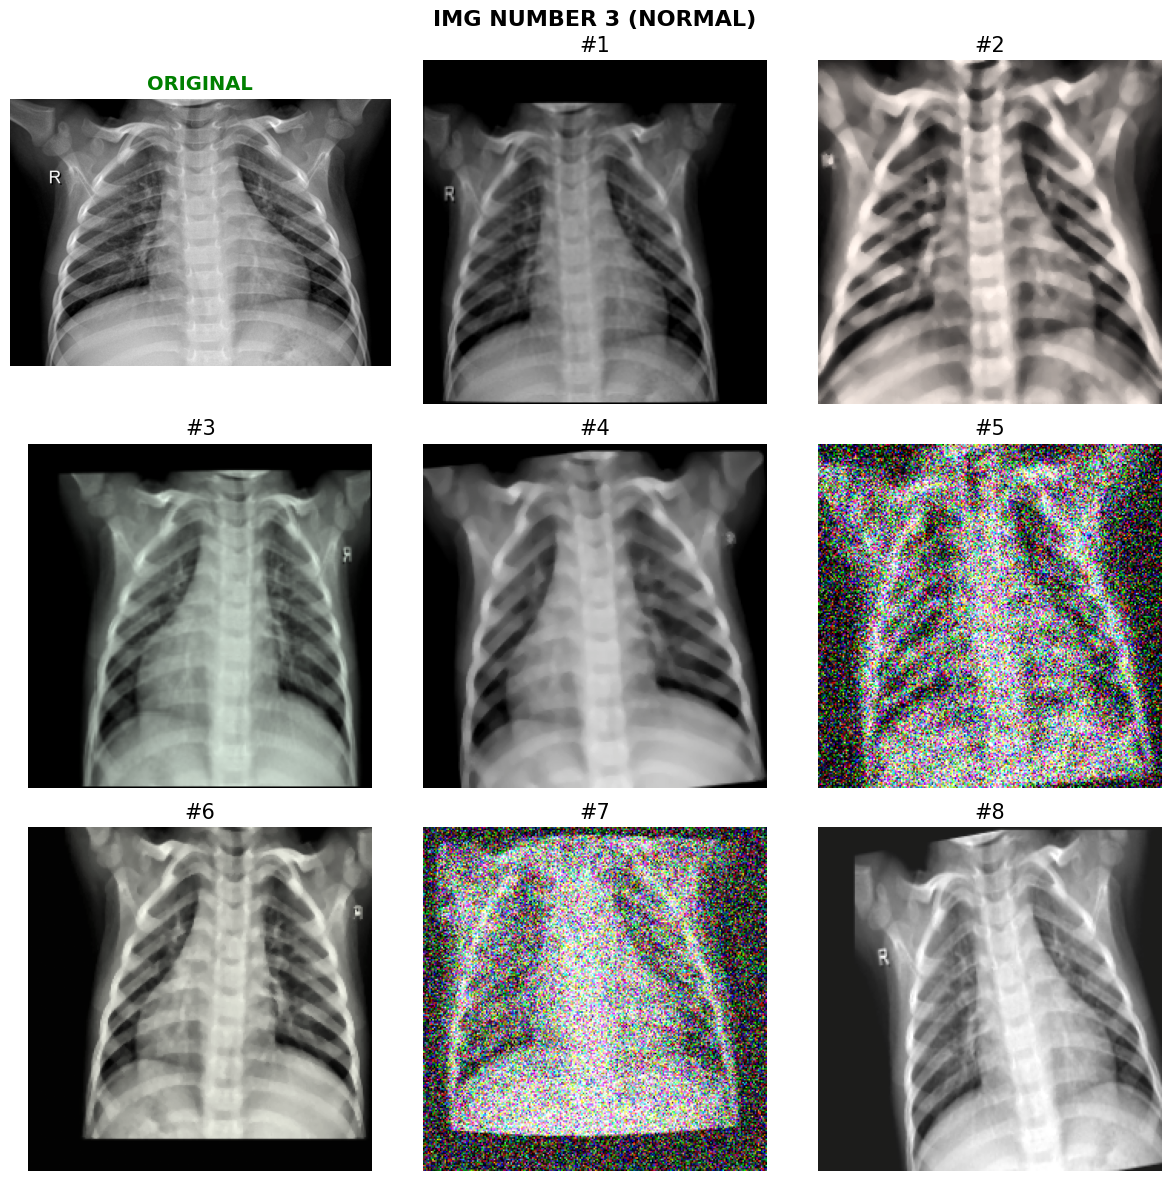


  DataLoaders ready!
  Batch size: 32
  Train batches: 148
  Val batches: 17
  Test batches: 20
Batch shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])

First 10 labels: [1, 1, 1, 2, 1, 1, 1, 2, 1, 2]
Label distribution: [9, 14, 9]


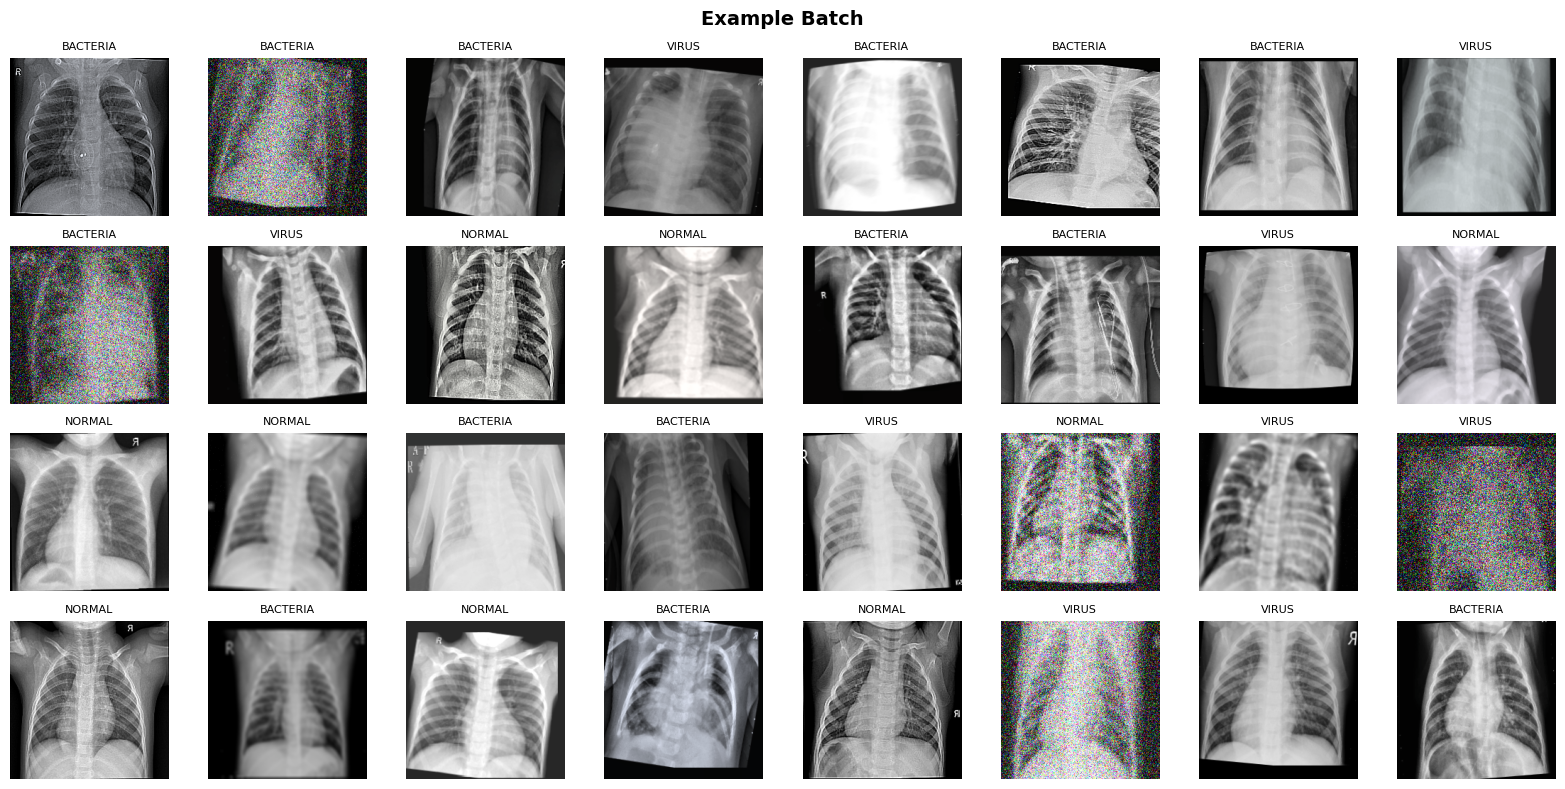

In [47]:
# retrouver les dossiers
importlib.invalidate_caches()
root = r"C:\Travaux\Epitech\Zoidberg2.0"
utility_dir = os.path.join(root, "pneumonia_knn", "utility")
pipeline_dir = os.path.join(root, "pneumonia_knn", "pipeline")
dataset_dir = os.path.join(root, "pneumonia_knn", "document", "result","model", "dataset")

# charger les fichiers
# --- on_the_fly_augmentation.ipynb
spec_on_the_fly_augmentation = NotebookFinder().find_spec("on_the_fly_augmentation", [root])
on_the_fly_augmentation = importlib.util.module_from_spec(spec_on_the_fly_augmentation)
spec_on_the_fly_augmentation.loader.exec_module(on_the_fly_augmentation)

# --- pneumonia_knn\utility\dataset.ipynb
spec_utility_dataset = NotebookFinder().find_spec("dataset", [utility_dir])
utility_dataset = importlib.util.module_from_spec(spec_utility_dataset)
spec_utility_dataset.loader.exec_module(utility_dataset)

# --- pneumonia_knn\notebooks\process\knn_pca.ipynb
spec_knn_pca = NotebookFinder().find_spec("knn_pca", [pipeline_dir])
knn_pca = importlib.util.module_from_spec(spec_knn_pca)

# --- pneumonia_knn\notebooks\process\knn_lda.ipynb
spec_knn_lda = NotebookFinder().find_spec("knn_lda", [pipeline_dir])
knn_lda = importlib.util.module_from_spec(spec_knn_lda)

# --- pneumonia_knn\notebooks\utility
spec_print = NotebookFinder().find_spec("prints", [utility_dir])
prints = importlib.util.module_from_spec(spec_print)
spec_print.loader.exec_module(prints)

## Chargement du dataset en array
Vérifie si un dataset (préprocessé) existe déjà dans un dossier spécifique. Sinon il se charge de convertir le dataset en array pour le model KNN.

⚠ Pour forcer le préprocessing (seulement la conversion en array) supprimer les fichier suivant :
    - [dataset_train.pkl](../documents/model/dataset/dataset_train.pkl)
    - [dataset_val.pkl](../documents/model/dataset/dataset_val.pkl)
    - [dataset_test.pkl](../documents/model/dataset/dataset_test.pkl)

In [48]:
hf_token = os.getenv("KEY_HUGGING_FACE")
local_paths = [
    os.path.join(dataset_dir, "dataset_train.pkl"),
    os.path.join(dataset_dir, "dataset_val.pkl"),
    os.path.join(dataset_dir, "dataset_test.pkl")
   ]
for local_path in local_paths:
    filename = os.path.basename(local_path)
    if not os.path.exists(local_path):
        print("Que souhaitez-vous faire ?")
        print("1. Utiliser le dataset déjà processé")
        print("2. Lancer le preprocessing du dataset")
        choice = input("Entrez 1 ou 2 : ")
        if choice == "1":
            print("Vous avez choisi de télécharger le dataset déjà processé deuis un repo HuggingFace.")
            try:
                print("Téléchargement en cours...")
                cached_path = hf_hub_download(
                    repo_id="Aidavef/chest-xray-pneumonia",
                    filename=f"KNN/models/v1/{filename}",
                    repo_type="model",
                    token=hf_token,
                    local_dir=dataset_dir,
                    local_files_only=False,
                    cache_dir=None  # Désactiver le cache
                )
                # Déplacer le fichier directement dans dataset_dir
                dest_path = os.path.join(dataset_dir, filename)
                shutil.move(cached_path, dest_path)

                # Nettoyer le dossier KNN créé automatiquement
                shutil.rmtree(os.path.join(dataset_dir, "KNN"), ignore_errors=True)
            except Exception as e:
                raise e
        elif choice == "2":
            print("Vous avez choisi de lancer le processing du dataset.")
            if filename == "dataset_train.pkl":
                joblib.dump((utility_dataset.apply_dataset_to_array(on_the_fly_augmentation.train_data, "train")), f'{dataset_dir}/dataset_train.pkl')
            elif filename == "dataset_test.pkl":
                joblib.dump((utility_dataset.apply_dataset_to_array(on_the_fly_augmentation.test_data, "test")), f'{dataset_dir}/dataset_test.pkl')
            elif filename == "dataset_val.pkl":
                joblib.dump((utility_dataset.apply_dataset_to_array(on_the_fly_augmentation.val_data, "val")), f'{dataset_dir}/dataset_val.pkl')

# charger les datasets
X_train, y_train = joblib.load(f'{dataset_dir}/dataset_train.pkl')
X_val, y_val = joblib.load(f'{dataset_dir}/dataset_val.pkl')
X_test, y_test = joblib.load(f'{dataset_dir}/dataset_test.pkl')



## Undersampling

In [49]:
rus = RandomUnderSampler(random_state=42)
X_train_balanced, y_train_balanced = rus.fit_resample(X_train, y_train)

classes, counts = np.unique(y_train_balanced, return_counts=True)
for c, n in zip(classes, counts):
    print(f"{c} : {n} images")

0 : 1168 images
1 : 1168 images
2 : 1168 images


## Implémentation KNN avec PCA
Ce code implémente un classificateur **K-Nearest Neighbors (KNN)** combiné à une réduction de dimensionnalité **PCA** pour la détection de pneumonie sur des radiographies pulmonaires.

⚠ Le détail du code se retrouve dans :
    - [knn_pca.ipynb](process/knn_pca.ipynb)

ModuleSpec(name='knn_pca', loader=<import_ipynb.NotebookLoader object at 0x000001B6C005E210>)
['dataset.ipynb', 'metrics.ipynb', 'prints.ipynb']


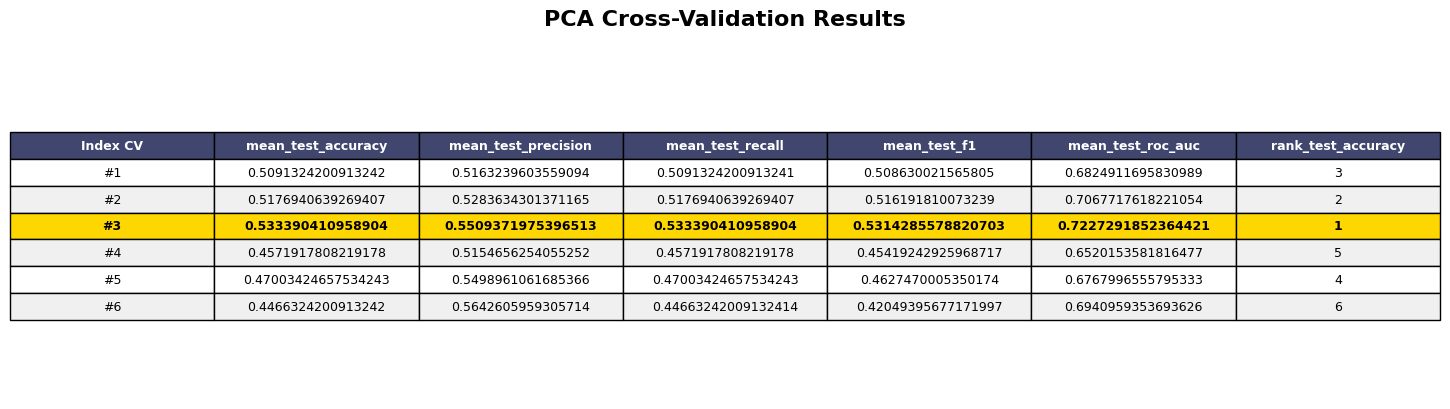

"\x1b ✅ Termination de l'implémentation de PCA pour KNN\x1b"

In [50]:
prints.bold(" 📉 Lancement de l'implémentation de PCA pour KNN")
knn_pca.X_train = X_train_balanced
knn_pca.X_test = X_test
knn_pca.y_train = y_train_balanced
knn_pca.y_test = y_test
print(spec_knn_pca)
spec_knn_pca.loader.exec_module(knn_pca)
prints.bold(" ✅ Termination de l'implémentation de PCA pour KNN")

## Impélmentation KNN avec LDA
Ce code implémente un classificateur **K-Nearest Neighbors (KNN)** combiné à une réduction de dimensionnalité **LDA** pour la détection de pneumonie sur des radiographies pulmonaires.

⚠ Le détail du code se retrouve dans :
    - [knn_lda.ipynb](process/knn_lda.ipynb)

In [51]:
prints.bold(" 📉 Lancement de l'implémentation de LDA pour KNN")
knn_lda.X_train = X_train_balanced
knn_lda.X_test = X_test
knn_lda.y_train = y_train_balanced
knn_lda.y_test = y_test
implementation = 'lda'
spec_knn_lda.loader.exec_module(knn_lda)
prints.bold(" ✅ Termination de l'implémentation de LDA pour KNN")

NameError: name 'implementation' is not defined

## Implémentation KNN avec PCA + LDA
Ce code implémente un classificateur **K-Nearest Neighbors (KNN)** combiné aux réductions de dimensionnalité **PCA** + **LDA** pour la détection de pneumonie sur des radiographies pulmonaires.

⚠ Le détail du code se retrouve dans :
    - [knn_lda.ipynb](process/knn_lda.ipynb)

In [ ]:
prints.bold(" 📉 Lancement de l'implémentation de PCA + LDA pour KNN")
result_lda_pca = knn_lda.implementation_with_LDA('knn_pca_lda_grid_search.pkl', y_train_balanced, knn_pca.X_train_pca, knn_pca.X_test_pca, y_test)
prints.bold(" ✅ Termination de l'implémentation de PCA + LDA pour KNN")